## АНАЛИЗ ЭФФЕКТИВНОСТИ ДВУХ ВАРИАНТОВ ПОСАДОЧНОЙ СТРАНИЦЫ
## ANALYSIS OF THE EFFECTIVENESS OF TWO LANDING PAGE VERSIONS

Туристическая фирма планирует запустить новую акцию, чтобы продать как можно больше туров. Команда разработала два варианта посадочной страницы официального сайта и провела A/B-тестирование. В результате эксперимента были собраны данные

**Задача**: проанализировать эффективность обоих вариантов посадочной страницы сразу по двум критериям — **конверсии покупки** и **ежедневному среднему чеку**.

Нужно убедиться, что A/B-тестирование было проведено корректно, проверить факт стабилизации метрик и обоснованно ответить на ключевой вопрос турагентства: какой вариант посадочной страницы более предпочтителен по метрикам конверсии и ежедневного среднего чека?

Итак, компания предлагает следующие варианты туров:

- Таиланд — 100 000 рублей;
- Турция — 60 000 рублей;
- Мальдивы — 200 000 рублей;
- Санкт-Петербург — 10 000 рублей;
- Камчатка — 150 000 рублей.

A travel agency plans to launch a new promotion to sell as many tours as possible. The team developed two landing page variations for the official website and conducted A/B testing. The experiment yielded the following data:

**Task**: Analyze the effectiveness of both landing page variations based on two criteria simultaneously: **purchase conversion** and **average daily check**.

We need to ensure that the A/B testing was conducted correctly, verify that the metrics have stabilized, and provide a sound answer to the travel agency's key question: which landing page variation is more preferable based on conversion and average daily check metrics?

So, the company offers the following tour options:

- Thailand — 100,000 rubles;
- Turkey — 60,000 rubles;
- Maldives — 200,000 rubles;
- St. Petersburg — 10,000 rubles;
- Kamchatka - 150,000 rubles.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import shapiro
from scipy.stats import ttest_ind
from scipy.stats import norm
from scipy.stats import t

In [4]:
data = pd.read_csv('ab_data_tourist.csv')
data.head()

,user_id,date,group,purchase,price
0,851104,2021-01-21,A,0,0
1,804228,2021-01-12,A,0,0
2,661590,2021-01-11,B,0,0
3,853541,2021-01-08,B,0,0
4,864975,2021-01-21,A,1,150000


### 1. Анализ данных и их предобработка
### 1. Data analysis and preprocessing

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   user_id   294478 non-null  int64 
 1   date      294478 non-null  object
 2   group     294478 non-null  object
 3   purchase  294478 non-null  int64 
 4   price     294478 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 11.2+ MB


Пропуски отсутствуют.

There are no gaps.

In [6]:
# Преобразуем дату к типу данных datetime
# Convert the date to the datetime data type
data['date'] = pd.to_datetime(data['date'], format='%Y-%m-%d')

In [7]:
# Проверим длительность теста по группам
# Посчитаем диапазон дат по группам
# Check the test duration by group
# Calculate the date range by group
group_dates = data.groupby('group')['date'].agg(['min', 'max', 'nunique'])

# Добавим длительность
# Let's add duration
group_dates['duration'] = group_dates['max'] - group_dates['min']
group_dates

,min,max,nunique,duration
group,,,,
A,2021-01-02,2021-01-24,23,22 days
B,2021-01-02,2021-01-24,23,22 days


Диапазоны в обеих группах совпадают, это видно по одинаковым датам начала тестирования и окончания тестирования.

The ranges in both groups are the same, as can be seen from the same start and end dates for testing.

In [8]:
# Проверим пользователей, попавших в обе группы
# Посчитаем количество пользователей по группам
# Let's check the users in both groups
# Let's count the number of users by group
users_in_groups = data.groupby('user_id')['group'].nunique()

# Смотрим на наличие пользователей в двух группах
# We look at the presence of users in two groups
users_in_groups[users_in_groups > 1]

# Посчитаем их количество
# Let's count their number
(users_in_groups > 1).sum()

1895

In [9]:
# Заносим "двойных" пользователей в отдельную переменную
# We put "double" users into a separate variable
bad_users = users_in_groups[users_in_groups > 1].index

# Удаляем этих пользователей из нашего датасета
# Remove these users from our dataset
data = data[~data['user_id'].isin(bad_users)]

# Делаем проверку
# We're doing a check
data.groupby('user_id')['group'].nunique().max()

1

### 2. Первичный анализ результатов A/B-тестирования
### 2. Initial analysis of A/B testing results

In [10]:
# Рассчитайте вспомогательные показатели для контрольной и тестовой групп
# Calculate auxiliary indicators for the control and test groups
metrics = data.groupby('group').agg(
    visits=('user_id', 'count'), # количество посещений сайта   # number of site visits
    purchases=('purchase', 'sum'), # суммарное количество совершённых покупок   # total number of purchases made
    revenue=('price', 'sum') # сумма всех покупок   # total purchases
)

metrics

,visits,purchases,revenue
group,,,
A,145307,17487,1417780000
B,145381,17290,1533010000


Количество посещения почти одинаковые. Можно сказать, что тест распределен корретно.

The number of visits is almost identical. It can be said that the test is distributed fairly.

In [11]:
# В каждой из групп рассчитываем конверсию и средний чек
# In each group we calculate the conversion rate and average check
metrics['conversion'] = (metrics['purchases']/metrics['visits'])*100
metrics['average_check'] = metrics['revenue']/metrics['purchases']

metrics

,visits,purchases,revenue,conversion,average_check
group,,,,,
A,145307,17487,1417780000,12.034520,81076.228055
B,145381,17290,1533010000,11.892888,88664.545980


На основе показателей конверсии и среднего чека в каждой из групп можно сделайте первичные выводы о результатах A/B-тестирования:

- конверсия в группе А выше, чем в группе В - вариант A увеличивает вероятность покупки

- средний чек в группе В выше, чем в группе А - вариант B увеличивает доход с одной покупки

Но нельзя делать финальный вывод.

Based on the conversion rates and average order value in each group, you can draw some initial conclusions about the A/B testing results:

- the conversion rate in group A is higher than in group B - variant A increases the likelihood of a purchase

- the average order value in group B is higher than in group A - variant B increases revenue per purchase

However, it's impossible to draw a final conclusion.

In [12]:
# Сравним варианты A/B по покупательской способности каждого из туров. 
# Для этого построим сводную таблицу, которая покажет зависимость количества продаж от группы и цены тура.
# Let's compare the A/B options based on the purchasing power of each tour.
# To do this, we'll create a pivot table that shows the relationship between sales volume and tour group and price.

# Определим общее количество визитов по группам
# Let's determine the total number of visits by group
total_users = data.groupby('group')['user_id'].count().reset_index()
total_users = total_users.rename(columns={'user_id': 'total_users'})

# Определим покупки по каждому туру (цене)
# Let's determine the purchases for each tour (price)
purchases_by_price = pd.pivot_table(
    data[data['purchase'] == 1],
    index=['group', 'price'],
    values='purchase',
    aggfunc='count'
).reset_index()

# Объединяем
# Unite
purchasing_power = purchases_by_price.merge(
    total_users,
    on='group',
    how='left'
)

# Считаем конверсию
# Calculating conversion
purchasing_power['conversion'] = (
    (purchasing_power['purchase'] / purchasing_power['total_users'])*100
)

# Сортируем для удобства
# Sorting for convenience
purchasing_power = purchasing_power.sort_values(['group', 'price'])

purchasing_power

,group,price,purchase,total_users,conversion
0,A,10000,5182,145307,3.566243
1,A,60000,5271,145307,3.627492
2,A,100000,1832,145307,1.260779
3,A,150000,3478,145307,2.393553
4,A,200000,1724,145307,1.186454
5,B,10000,5201,145381,3.577496
6,B,60000,1730,145381,1.189977
7,B,100000,5227,145381,3.595380
8,B,150000,3438,145381,2.364821
9,B,200000,1694,145381,1.165214


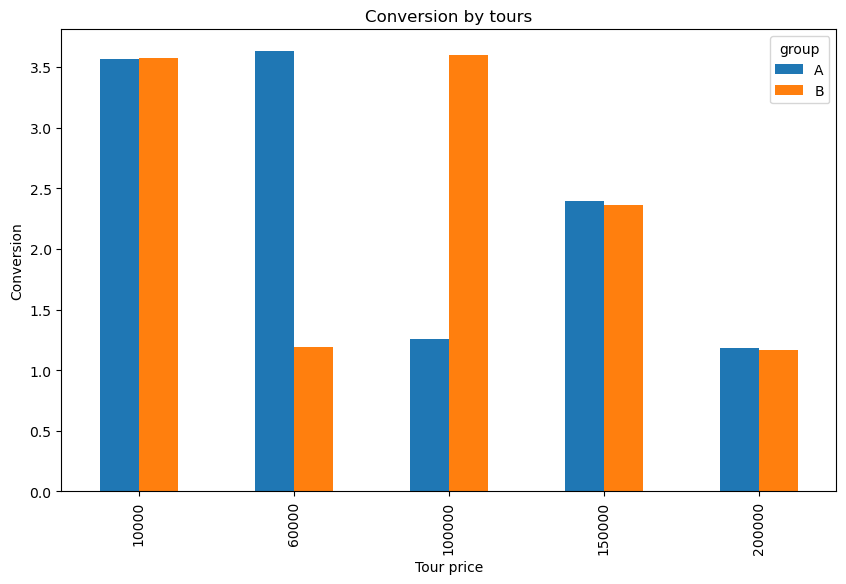

In [13]:
# Визуализируйте полученную сводную таблицу
# Visualize the resulting pivot table
pivot = purchasing_power.pivot(index='price', columns='group', values='conversion')

pivot.plot(kind='bar', figsize=(10, 6))

plt.title('Conversion by tours')
plt.xlabel('Tour price')
plt.ylabel('Conversion')

plt.show()

В группе B наблюдается наибольшая конверсия для тура в Таиланд, тогда как в группе A данный тур конвертируется значительно хуже.
В то же время в группе A наиболее высокая конверсия наблюдается для тура в Турция, тогда как в группе B этот тур показывает более низкую конверсию.
По остальным направлениям существенных различий между группами не наблюдается.

Group B shows the highest conversion rate for the Thailand tour, while in Group A this tour converts significantly less.
Meanwhile, in Group A, the highest conversion rate is observed for the Turkey tour, while in Group B this tour converts less.
No significant differences are observed between the groups for the other destinations.

### 3. Анализ данных на предмет стабилизации метрик
### 3. Data analysis for metric stabilization

In [14]:
# Сгруппируем данные по дате и группе тестирования и построим таблицу с ежедневными данными результатов проведения A/B-тестирования.
# Let's group the data by date and testing group and build a table with daily data of the A/B testing results.
daily_data = data.groupby(['date', 'group']).agg(
    visits=('user_id', 'count'),      # количество посещений  # number of visits
    purchases=('purchase', 'sum'),    # количество покупок    # number of purchases
    revenue=('price', 'sum')          # сумма покупок         # purchase amount
).reset_index()

# Рассчитываем ежедневную конверсию по группам
# Calculate daily conversion by group
daily_data['conversion'] = (daily_data['purchases']/daily_data['visits'])*100

# Рассчитываем ежедневный средний чек по группам
# Calculate the daily average bill by group
daily_data['average_check'] = daily_data['revenue']/daily_data['purchases']

daily_data.head()

,date,group,visits,purchases,revenue,conversion,average_check
0,2021-01-02,A,2854,359,29410000,12.578837,81922.005571
1,2021-01-02,B,2861,345,29660000,12.058721,85971.014493
2,2021-01-03,A,6596,748,62000000,11.340206,82887.700535
3,2021-01-03,B,6619,754,65960000,11.391449,87480.106101
4,2021-01-04,A,6566,799,64250000,12.168748,80413.016270


In [15]:
# Рассчитаем кумулятивные показатели
# вычисляем кумулятивную сумму количества посетителей
# Calculate cumulative indicators
# calculate the cumulative sum of the number of visitors
daily_data['cum_visits'] = daily_data.groupby(['group'])['visits'].cumsum()

# вычисляем кумулятивную кумулятивное количество покупок
# calculate the cumulative cumulative number of purchases
daily_data['cum_purchases'] = daily_data.groupby(['group'])['purchases'].cumsum()

# вычисляем кумулятивную сумму количества покупок
# calculate the cumulative sum of the number of purchases
daily_data['cum_revenue'] = daily_data.groupby(['group'])['revenue'].cumsum()

# расчитываем кумулятивную конверсию
# calculate cumulative conversion
daily_data['cum_conversion'] = daily_data['cum_purchases']/daily_data['cum_visits'] * 100

# расчитываем кумулятивный средний чек
# calculate the cumulative average bill
daily_data['cum_average_check'] = (
    daily_data['cum_revenue'] / daily_data['cum_purchases']
).replace([float('inf'), -float('inf')], 0)

daily_data.head()

,date,group,visits,purchases,revenue,conversion,average_check,cum_visits,cum_purchases,cum_revenue,cum_conversion,cum_average_check
0,2021-01-02,A,2854,359,29410000,12.578837,81922.005571,2854,359,29410000,12.578837,81922.005571
1,2021-01-02,B,2861,345,29660000,12.058721,85971.014493,2861,345,29660000,12.058721,85971.014493
2,2021-01-03,A,6596,748,62000000,11.340206,82887.700535,9450,1107,91410000,11.714286,82574.525745
3,2021-01-03,B,6619,754,65960000,11.391449,87480.106101,9480,1099,95620000,11.592827,87006.369427
4,2021-01-04,A,6566,799,64250000,12.168748,80413.016270,16016,1906,155660000,11.900599,81668.415530


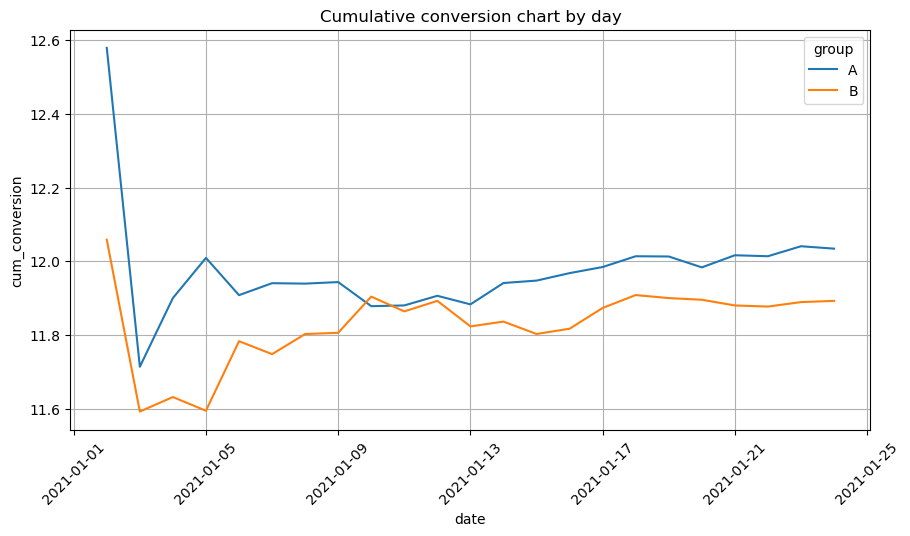

In [16]:
# А теперь построим графики кумулятивной конверсии по дням в каждой группе
# создаём фигуру размером 8x4
# Now let's plot cumulative conversion charts by day in each group.
# Create an 8x4 shape.
fig = plt.figure(figsize=(8, 4))
# добавляем систему координат
# add a coordinate system
ax = fig.add_axes([1, 1, 1, 1])
# строим lineplot для кумулятивной конверсии во времени в каждой группе
# plot a lineplot for cumulative conversion over time in each group
sns.lineplot(x='date', y='cum_conversion', data=daily_data, hue='group', ax=ax)
# задаём подпись к графику
# set a caption for the graph
ax.set_title('Cumulative conversion chart by day')
# задаём поворот меток на оси абсцисс
# set the rotation of the labels on the x-axis
ax.xaxis.set_tick_params(rotation = 45)
# задаём отображение сетки
# set the grid display
ax.grid(True);

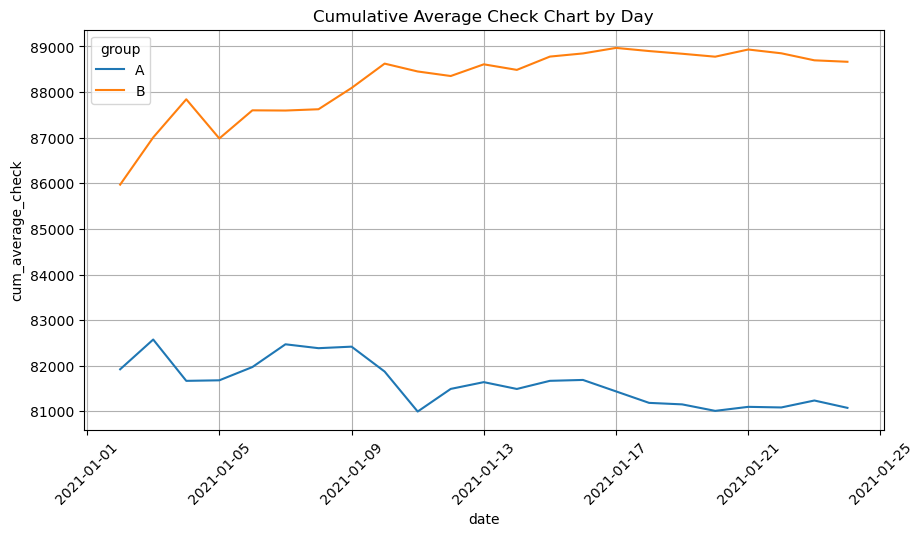

In [17]:
# Построим графики кумулятивного среднего чека по дням в каждой группе
# создаём фигуру размером 8x4
# Let's plot graphs of the cumulative average check by day in each group
# Create an 8x4 shape
fig = plt.figure(figsize=(8, 4))
# добавляем систему координат
# add a coordinate system
ax = fig.add_axes([1, 1, 1, 1])
# строим lineplot для кумулятивного среднего чека в каждой группе
# build a lineplot for the cumulative average check in each group
sns.lineplot(x='date', y='cum_average_check', data=daily_data, hue='group', ax=ax)
# задаём подпись к графику
# set a caption for the graph
ax.set_title('Cumulative Average Check Chart by Day')
# задаём поворот меток на оси абсцисс
# set the rotation of the labels on the x-axis
ax.xaxis.set_tick_params(rotation = 45)
# задаём отображение сетки
# set the grid display
ax.grid(True);

По графикам видно, что метрики стабилизировались во времени, и можно назвать A/B-тест завершённым.
Визуально видно, что кумулятивная конверсия в группе А выше, но кумулятивный средний чек выше в группе В.

The graphs show that the metrics have stabilized over time, and the A/B test can be called completed.
Visually, you can see that the cumulative conversion in group A is higher, but the cumulative average check is higher in group B.

### 4. Статистический анализ результатов A/B-тестирования
### 4. Statistical analysis of A/B testing results

Теперь определим, **есть ли статистическая разница между конверсиями в группах А и B?**

Тип данных purchase - бинарный (0/1), значит сравниваем доли (пропорции). Тогда воспользуемся Z-тестом для долей.
Сформулируем гипотезы:

 - Нулевая гипотеза (отсутствие эффекта): конверсии в группах A и B равны
    $$H_0: p_A = p_B$$
  
 - Альтернативная гипотеза (наличие эффекта): конверсии в группах A и B не равны
    $$H_1: p_A \neq p_B$$
  
Определим уровень значимости alpha = 0.05.

Now let's determine whether there is a statistical difference between conversions in groups A and B.

The purchase data type is binary (0/1), so we're comparing shares (proportions). We'll then use the Z-test for shares.
Let's formulate the hypotheses:

- Null hypothesis (no effect): conversions in groups A and B are equal
$$H_0: p_A = p_B$$

- Alternative hypothesis (presence of effect): conversions in groups A and B are not equal
$$H_1: p_A \neq p_B$$

We set the significance level to alpha = 0.05.

In [18]:
alpha = 0.05 # уровень значимости  # significance level
# вычисляем значение p-value для z-теста для пропорций
# calculate the p-value for the z-test for proportions
_, p_value = proportions_ztest(
    count=metrics['purchases'], # число «успехов»      # number of "successes"
    nobs=metrics['visits'], # общее число наблюдений   # total number of observations
    alternative='two-sided',
)

# выводим результат на экран
# display the result on the screen
print('p-value: ', round(p_value, 3))

# сравниваем полученное p-value с уровнем значимости
# compare the obtained p-value with the significance level
if (p_value <= alpha):
    print("Отвергаем нулевую гипотезу в пользу альтернативной")
    print("We reject the null hypothesis in favor of the alternative one")
else:
    print("У нас нет оснований отвергнуть нулевую гипотезу")
    print("We have no reason to reject the null hypothesis")

p-value:  0.239
У нас нет оснований отвергнуть нулевую гипотезу
We have no reason to reject the null hypothesis


Z-тест показал, что нельзя сказать о наличии статистической разница между конверсиями в группах А и B.

The Z-test showed that there was no statistical difference between conversions in groups A and B.

Определим, **есть ли статистическая разница между ежедневными средними чеками в группах А и B?**

Тип данных - ежедневный average_check - непрерывная величина. Нужно определить распределение на нормальность прежде чем выбрать статистический тест. Для этого воспользуемся тестом Шапиро-Уилка.

 - Нулевая гипотеза — распределение нормальное
 - Альтернативная гипотеза — распределение отлично от нормального

Определим уровень значимости alpha = 0.05.

Let's determine whether **there is a statistical difference between the daily average checks in groups A and B.**

Data type: daily average_check - continuous variable. We need to determine the normality of the distribution before choosing a statistical test. For this, we'll use the Shapiro-Wilk test.

- Null hypothesis: Normal distribution
- Alternative hypothesis: Non-normal distribution

We'll set the significance level to alpha = 0.05.

In [19]:
alpha = 0.05 # уровень значимости  # significance level
# вычисляем результат теста Шапиро — Уилка для выборок
# calculate the result of the Shapiro-Wilk test for samples
shapiro_result_a = shapiro(daily_data[daily_data['group'] == 'A']['average_check'])
shapiro_result_b = shapiro(daily_data[daily_data['group'] == 'B']['average_check'])
print('p-value группы А', round(shapiro_result_a.pvalue, 2))
print('p-value группы B', round(shapiro_result_b.pvalue, 2))

# сравниваем полученное p-value для группы А с уровнем значимости
# compare the obtained p-value for group A with the significance level
if shapiro_result_a.pvalue <= alpha:
    print("Отвергаем нулевую гипотезу в пользу альтернативной. Распределение в группе А отлично от нормального.")
    print("We reject the null hypothesis in favor of the alternative. The distribution in group A is different from normal.")
else:
    print("Принимаем нулевую гипотезу. Распределение в группе А является нормальным.")
    print("We accept the null hypothesis. The distribution in group A is normal.")

# сравниваем полученное p-value для группы B с уровнем значимости
# compare the obtained p-value for group B with the significance level
if shapiro_result_b.pvalue <= alpha:
    print("Отвергаем нулевую гипотезу в пользу альтернативной. Распределение в группе B отлично от нормального.")
    print("We reject the null hypothesis in favor of the alternative. The distribution in group B is different from normal.")
else:
    print("Принимаем нулевую гипотезу. Распределение в группе B является нормальным.")
    print("We accept the null hypothesis. The distribution in group B is normal.")

p-value группы А 0.25
p-value группы B 0.09
Принимаем нулевую гипотезу. Распределение в группе А является нормальным.
We accept the null hypothesis. The distribution in group A is normal.
Принимаем нулевую гипотезу. Распределение в группе B является нормальным.
We accept the null hypothesis. The distribution in group B is normal.


Так как распределения являются нормальными, применим двухвыборочный T-тест для сравнения средних. Сформулируем гипотезы:

- Нулевая гипотеза (об отсутствии эффекта): средний чек группы А равняется среднему чеку группы В
   $$H_0: \mu_A = \mu_B$$

- Альтернативная гипотеза (о наличии эффекта): средний чек группы А отличается от среднего чека группы В
   $$H_1: \mu_A \neq \mu_B$$

Определим уровень значимости alpha = 0.05.

Since the distributions are normal, we will use a two-sample t-test to compare means. Let's formulate the hypotheses:

- Null hypothesis (no effect): the average check for Group A is equal to the average check for Group B
$$H_0: \mu_A = \mu_B$$

- Alternative hypothesis (the presence of an effect): the average check for Group A differs from the average check for Group B
$$H_1: \mu_A \neq \mu_B$$

We define the significance level as alpha = 0.05.

In [20]:
alpha = 0.05 # уровень значимости # significance level
# вычисляем результат T-теста для выборок
# calculate the T-test result for samples
results = ttest_ind(
    a=daily_data[daily_data['group'] == 'A']['average_check'],
    b=daily_data[daily_data['group'] == 'B']['average_check'],
    alternative='two-sided'
)
print('p-value:', round(results.pvalue, 2))

# сравниваем полученное p-value с уровнем значимости
# compare the obtained p-value with the significance level
if results.pvalue <= alpha:
    print("Отвергаем нулевую гипотезу в пользу альтернативной")
    print("We reject the null hypothesis in favor of the alternative one.")
else:
    print("У нас нет оснований отвергнуть нулевую гипотезу")
    print("We have no reason to reject the null hypothesis.")

p-value: 0.0
Отвергаем нулевую гипотезу в пользу альтернативной
We reject the null hypothesis in favor of the alternative one.


In [21]:
# T-тест показал наличие отличия среднего чека группы А от среднего чека группы В
# Посмотрим в какую сторону отличие
# The T-test showed a difference between the average bill for Group A and the average bill for Group B.
# Let's see which way the difference lies.
daily_data.groupby('group')['average_check'].mean()

group
A    80969.285099
B    88575.715514
Name: average_check, dtype: float64

По результатам t-теста при уровне значимости 0.05 была обнаружена статистически значимая разница между средними чеками групп A и B.
При этом средний чек в группе B выше, чем в группе A.

A t-test at a significance level of 0.05 revealed a statistically significant difference between the average receipts of Groups A and B.
Moreover, the average receipt in Group B was higher than in Group A.

Чтобы подкрепить результаты статистических тестов, построим **95 % доверительные интервалы** для:
 - конверсий в каждой из групп
 - разницы конверсий в группах
 - ежедневного среднего чека в каждой из групп

To support the results of the statistical tests, we will construct **95% confidence intervals** for:
- conversions in each group
- the difference in conversions between groups
- the daily average order value in each group

In [22]:
# При построении доверительного интервала для конверсий в каждой из групп, будем использовать доверительный интервал для пропорций
# фильтруем данные группы А
# When constructing a confidence interval for conversions in each group, we will use the confidence interval for proportions
# filter the data for group A
a_data = metrics.loc['A']
# фильтруем данные группы B
# filter group B data
b_data = metrics.loc['B']

# Создадим функцию для расчета доверительного интервала
# Let's create a function to calculate the confidence interval
def proportion_conf_interval(x_p, n, gamma=0.95):  
    alpha = 1 - gamma # уровень значимости                     # significance level
    z_crit = -norm.ppf(alpha/2) # z-критическое                # z-critical
    eps = z_crit * (x_p * (1 - x_p) / n) ** 0.5 # погрешность  # error
    lower_bound = x_p - eps # левая (нижняя) граница           # left (bottom) border
    upper_bound = x_p + eps # правая (верхняя) граница         # right (upper) border
    # возвращаем кортеж из границ интервала
    # return a tuple of interval bounds
    return lower_bound, upper_bound

In [23]:
# Теперь применим нашу функцию к данным группы А и группы B, результат умножим на 100 % и округлим до сотых
# строим доверительный интервал для конверсии в группе А
# Now we apply our function to the data from Group A and Group B, multiply the result by 100%, and round to hundredths.
# We construct a confidence interval for the conversion in Group A.
lower_bound_a, upper_bound_a  = proportion_conf_interval(
    x_p=a_data['purchases']/a_data['visits'], # выборочная пропорция  # sampling proportion
    n=a_data['visits'] # размер выборки    # sample size
)

# строим доверительный интервал для конверсии в группе B
# we construct a confidence interval for the conversion in group B
lower_bound_b, upper_bound_b  = proportion_conf_interval(
    x_p=b_data['purchases']/b_data['visits'], # выборочная пропорция   # sampling proportion
    n=b_data['visits'] # размер выборки    # sample size
)

# выводим результат
# display the result
print('Доверительный интервал для конверсии в группе А: {}'.format((round(lower_bound_a * 100, 2), round(upper_bound_a * 100, 2))))
print('Доверительный интервал для конверсии в группе B: {}'.format((round(lower_bound_b * 100, 2), round(upper_bound_b * 100, 2))))
print('Confidence interval for conversion in group A: {}'.format((round(lower_bound_a * 100, 2), round(upper_bound_a * 100, 2))))
print('Confidence interval for conversion in group B: {}'.format((round(lower_bound_b * 100, 2), round(upper_bound_b * 100, 2))))

Доверительный интервал для конверсии в группе А: (11.87, 12.2)
Доверительный интервал для конверсии в группе B: (11.73, 12.06)
Confidence interval for conversion in group A: (11.87, 12.2)
Confidence interval for conversion in group B: (11.73, 12.06)


Доверительные интервалы для конверсий в группах A и B пересекаются, что указывает на отсутствие явных различий между группами. Тем не менее, для окончательного вывода необходимо рассмотреть доверительный интервал разности конверсий.

The confidence intervals for conversions in groups A and B overlap, indicating no clear differences between the groups. However, to draw a final conclusion, it is necessary to examine the confidence interval for the difference in conversions.

In [24]:
# Построим доверительный интервал разности конверсий
# Создадим функцию для расчета доверительного интервала разности конверсий
# Let's build a confidence interval for the difference in conversions
# Let's create a function to calculate the confidence interval for the difference in conversions
def diff_proportion_conf_interval(x_p, n, gamma=0.95):
    alpha = 1 - gamma # уровень значимости                                   # significance level
    diff = x_p[1] - x_p[0] # выборочная разница конверсий групп B и A        # sample difference in conversions of groups B and A
    z_crit = -norm.ppf(alpha/2) # z-критическое                              # z-critical
    eps = z_crit * (x_p[0] * (1 - x_p[0])/n[0] + x_p[1] * (1 - x_p[1])/n[1]) ** 0.5 # погрешность  # error
    lower_bound = diff - eps # левая (нижняя) граница                        # left (bottom) border
    upper_bound = diff + eps # правая (верхняя) граница                      # right (upper) border
    # возвращаем кортеж из  границ интервала
    # return a tuple of interval bounds
    return lower_bound, upper_bound

# размеры выборок групп А и B
# sample sizes of groups A and B
n = [a_data['visits'], b_data['visits']]
# выборочная пропорция групп A и B
# sample proportion of groups A and B
x_p = [a_data['purchases']/a_data['visits'], b_data['purchases']/b_data['visits']]

# строим доверительный интервал для разности пропорций
# construct a confidence interval for the difference in proportions
lower_bound, upper_bound = diff_proportion_conf_interval(x_p=x_p, n=n)

# выводим результат
# display the result
print('Доверительный интервал для разности конверсий: {}'.format((round(lower_bound*100, 2), round(upper_bound*100, 2))))
print('Confidence interval for the difference in conversions: {}'.format((round(lower_bound*100, 2), round(upper_bound*100, 2))))

Доверительный интервал для разности конверсий: (-0.38, 0.09)
Confidence interval for the difference in conversions: (-0.38, 0.09)


Доверительный интервал разности конверсий (B − A) составил (-0.38, 0.09).
Поскольку интервал содержит 0, можно сделать вывод об отсутствии статистически значимых различий между группами.

The confidence interval for the difference in conversion rates (B − A) was (-0.38, 0.09).
Since the interval contains 0, it can be concluded that there are no statistically significant differences between the groups.

In [25]:
# Для постоения доверительного интервала ежедневного среднего чека в каждой из групп будем строить
# доверительный интервал для среднего через t-распределение
# Функция нахождения доверительный интервал для среднего через t-распределение
# To construct a confidence interval for the daily average bill in each group, we will construct a
# confidence interval for the mean using the t-distribution
# Function for finding a confidence interval for the mean using the t-distribution
def t_mean_conf_interval(x_mean, x_std, n, gamma=0.95):  
    alpha = 1 - gamma # уровень значимости                  # significance level
    t_crit = -t.ppf(alpha/2, n - 1) # t-критическое         # t-critical 
    eps = t_crit * x_std/(n ** 0.5) # погрешность           # error
    lower_bound = x_mean - eps # левая (нижняя) граница     # left (bottom) border
    upper_bound = x_mean + eps # правая (верхняя) граница   # right (upper) border
    # возвращаем кортеж из границ интервала
    # return a tuple of interval bounds
    return lower_bound, upper_bound

In [26]:
# фильтруем данные по группам
# filter data by groups
a_checks = daily_data[daily_data['group'] == 'A']['average_check']
b_checks = daily_data[daily_data['group'] == 'B']['average_check']

# cтроим доверительный интервал для среднего для каждой группы
# construct a confidence interval for the mean for each group
lower_bound_a, upper_bound_a = t_mean_conf_interval(x_mean=a_checks.mean(),
                                                    x_std=a_checks.std(ddof=1),
                                                    n=len(a_checks))
lower_bound_b, upper_bound_b = t_mean_conf_interval(x_mean=b_checks.mean(),
                                                    x_std=b_checks.std(ddof=1),
                                                    n=len(b_checks))

# выводим результат
# display the result
print('Доверительный интервал для группы А: {}'.format((round(lower_bound_a), round(upper_bound_a))))
print('Доверительный интервал для группы В: {}'.format((round(lower_bound_b), round(upper_bound_b))))
print('Confidence interval for group A: {}'.format((round(lower_bound_a), round(upper_bound_a))))
print('Confidence interval for group В: {}'.format((round(lower_bound_b), round(upper_bound_b))))

Доверительный интервал для группы А: (79630, 82308)
Доверительный интервал для группы В: (87626, 89526)
Confidence interval for group A: (79630, 82308)
Confidence interval for group В: (87626, 89526)


Доверительные интервалы для среднего чека в группах A и B не пересекаются: (79 630; 82 308) для группы A и (87 626; 89 526) для группы B. Это свидетельствует о статистически значимом превосходстве среднего чека в группе B.

The confidence intervals for the average check in groups A and B do not intersect: (79,630; 82,308) for group A and (87,626; 89,526) for group B. This indicates a statistically significant superiority of the average check in group B.

### 5. Общий вывод по результатам A/B-теста
### 5. General conclusion based on the A/B test results

В ходе A/B-тестирования не было выявлено статистически значимых различий в конверсии между группами A и B: доверительные интервалы пересекаются, а результаты статистического теста не дают оснований отвергнуть нулевую гипотезу.

В то же время средний чек в группе B оказался статистически значимо выше, чем в группе A: доверительные интервалы не пересекаются, а результаты t-теста подтверждают наличие различий.

Таким образом, второй вариант посадочной страницы является более предпочтительным, так как он обеспечивает более высокий средний доход с пользователя.

The A/B testing revealed no statistically significant differences in conversion rates between Groups A and B: the confidence intervals overlap, and the statistical test results provide no basis to reject the null hypothesis.

However, the average order value in Group B was statistically significantly higher than in Group A: the confidence intervals do not overlap, and the t-test results confirm the differences.

Therefore, the second landing page variant is preferable, as it yields a higher average revenue per user.